# 01 - The corpus and the audit funnel

**Question this notebook answers.** Of the MCP servers published to the official registry, how many can actually be audited at all -- and is the set that survives representative of the ecosystem, or the easy tail of it?

**Reads.** `data/processed/scale_run.json`

Run top to bottom. Every number below is computed from the raw file named above; nothing is hard-coded.

In [1]:
import json, sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "notebooks"))
sys.path.insert(0, str(ROOT / "src"))
import matplotlib.pyplot as plt
import nbstyle
from nbstyle import BLUE, ORANGE, AQUA, ORDINAL, INK, INK_2, MUTED, CRITICAL
nbstyle.use_style()
PROC = ROOT / "data" / "processed"
RESULTS = ROOT / "results"

def load(name):
    p = PROC / name
    if not p.exists():
        raise FileNotFoundError(
            f"{p} is missing. Raw traces are gitignored; regenerate with the "
            f"command in results/README.md.")
    return json.loads(p.read_text(encoding="utf-8"))

print("reading from", PROC)

reading from F:\UIU\12th\CS\Paper work\repo\data\processed


## The funnel

Every candidate was launched in a locked-down container and driven through one honest and one tampered trial.

In [2]:
from collections import Counter
scale = load("scale_run.json")
launched = [r for r in scale if r.get("tool_count") is not None]
ok       = [r for r in scale if r.get("status") == "ok"]
landed   = [r for r in ok if (r.get("tampered") or {}).get("attack_landed")]

stages = [("Registry candidates", len(scale)),
          ("Launched, answered tools/list", len(launched)),
          ("Usable write tool, both trials", len(ok)),
          ("Attack actually landed", len(landed))]
for label, n in stages:
    print(f"{label:<34} {n:>6}  {100*n/len(scale):>5.1f}%")

Registry candidates                  8692  100.0%
Launched, answered tools/list        4121   47.4%
Usable write tool, both trials       1242   14.3%
Attack actually landed                128    1.5%


saved results/figures/funnel.png


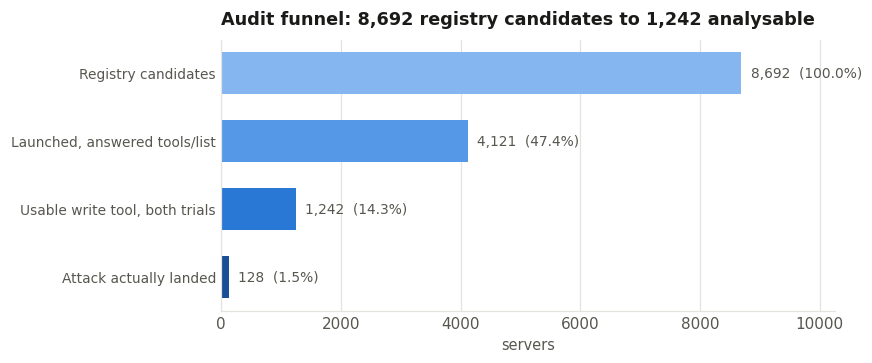

In [3]:
fig, ax = plt.subplots(figsize=(7.2, 3.2))
labels = [s[0] for s in stages]; vals = [s[1] for s in stages]
bars = ax.barh(range(len(vals))[::-1], vals, color=ORDINAL, height=0.62)
ax.set_yticks(range(len(vals))[::-1]); ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel("servers"); ax.grid(axis="x"); ax.grid(axis="y", visible=False)
ax.set_title("Audit funnel: 8,692 registry candidates to 1,242 analysable")
for b, v in zip(bars, vals):
    ax.annotate(f"{v:,}  ({100*v/len(scale):.1f}%)",
                (b.get_width(), b.get_y() + b.get_height()/2),
                xytext=(6, 0), textcoords="offset points",
                va="center", fontsize=9, color=INK_2)
ax.set_xlim(0, len(scale)*1.18)
nbstyle.save(fig, "funnel", RESULTS); plt.show()

## Why servers dropped out

In [4]:
for k, v in Counter(r.get("status") for r in scale).most_common():
    print(f"{k:<22} {v:>6}")

failed                   3123
no_write_tool_found      2879
host_timeout             1447
ok                       1242
no_result_written           1


## Is the analysed set representative?

Compare the servers that survived to the audit against those that launched and then dropped out. If the survivors are systematically more auditable, any detection rate measured on them is an upper bound for the ecosystem.

In [5]:
import statistics as stats
drop = [r for r in launched if r.get("status") != "ok"]

def class_mix(group):
    agg = Counter()
    for r in group:
        for k, v in (r.get("coverage") or {}).items():
            agg[k] += v
    total = sum(agg.values()) or 1
    return total, {k: 100*agg.get(k, 0)/total for k in ("A0","A1","A2","A3")}

for label, g in (("analysed (ok)", ok), ("launched, dropped", drop)):
    total, mix = class_mix(g)
    med = stats.median([r["tool_count"] for r in g])
    print(f"{label:<20} n={len(g):>5}  median tools={med:>4.0f}  tools={total:>6}  "
          + "  ".join(f"{k}={mix[k]:>5.1f}%" for k in ("A0","A1","A2","A3")))

analysed (ok)        n= 1242  median tools=  14  tools= 38612  A0= 36.7%  A1=  9.2%  A2= 53.0%  A3=  1.1%
launched, dropped    n= 2879  median tools=   6  tools= 37057  A0= 81.5%  A1= 18.5%  A2=  0.0%  A3=  0.0%


saved results/figures/selection_effect.png


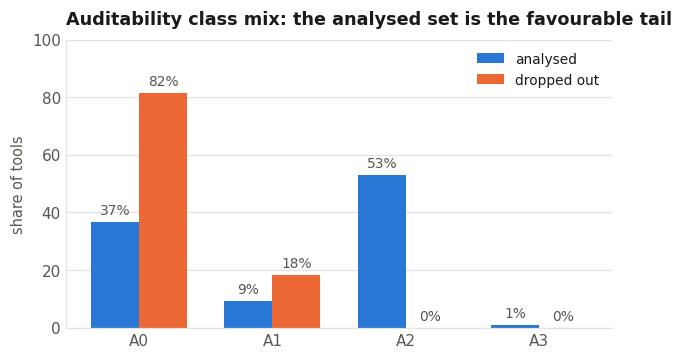

In [6]:
import numpy as np
classes = ["A0","A1","A2","A3"]
_, mix_ok   = class_mix(ok)
_, mix_drop = class_mix(drop)
x = np.arange(len(classes)); w = 0.36

fig, ax = plt.subplots(figsize=(6.4, 3.4))
b1 = ax.bar(x - w/2, [mix_ok[c]   for c in classes], w, color=BLUE,   label="analysed")
b2 = ax.bar(x + w/2, [mix_drop[c] for c in classes], w, color=ORANGE, label="dropped out")
nbstyle.bar_labels(ax, b1, fmt="{:.0f}%"); nbstyle.bar_labels(ax, b2, fmt="{:.0f}%")
ax.set_xticks(x); ax.set_xticklabels(classes)
ax.set_ylabel("share of tools"); ax.set_ylim(0, 100)
ax.set_title("Auditability class mix: the analysed set is the favourable tail")
ax.legend(loc="upper right")
nbstyle.save(fig, "selection_effect", RESULTS); plt.show()

**A0** means no relation is derivable, so no client-side check exists. The gap between the two bars at A0 and A2 is the selection effect, in one picture.